# ECON N171: Economic Development
## Lecture 8 — Replication: The Agricultural Productivity Gap
**Instructor: Rajveer Jat | Summer 2026**

*⚠️ Data Note: The data used in this notebook is synthetic. It is constructed to replicate the key empirical patterns of the paper but does not use the actual restricted microdata (KLEMS, NSS, PLFS, IHDS). All qualitative findings and the direction of results are faithful to the published paper.*
---

## The Paper

**Jat, R. and Ramaswami, B. (2026)**  
*"The Agricultural Productivity Gap: Informality Matters"*  
Journal of Development Economics, Volume 178, January 2026, 103617

### The Question

Workers in agriculture earn far less than workers outside agriculture. This is the **Agricultural Productivity Gap (APG)**. Under perfect labor mobility, workers should move until wages equalize — so why does the gap persist?

Standard adjustments narrow the gap:
1. **Hours** — agricultural workers work fewer hours per week
2. **Human capital** — agricultural workers have fewer years of schooling
3. **Labor share** — agriculture retains a larger share of output as wages

**This paper's contribution:** Even after all three adjustments, the gap depends entirely on *which* non-farm sectors you compare agriculture to. When agriculture is compared to **highly informal** non-farm sectors, the corrected APG is not statistically different from 1. The gap is a formal/informal phenomenon — not an agriculture/non-agriculture phenomenon.

### Data

India's KLEMS dataset — 27 sectors, 5 time periods (1999–2023) — merged with NSS/PLFS/IHDS household surveys. The underlying microdata is restricted. We use synthetic data that replicates the key empirical patterns.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.kernel_regression import KernelReg

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
print('Libraries loaded.')

Libraries loaded.


---
## Part 1: Build the Dataset

The KLEMS dataset has 27 sectors observed across 5 time periods.

**Key design principle:** We build the data so the true underlying relationship reflects the paper's finding — VA per worker in non-farm sectors is a **decreasing function of informality**. Highly informal non-farm sectors have productivity close to agriculture. Formal sectors have productivity far above agriculture.

This is not an assumption we impose — it is what the actual Indian data shows.

In [2]:
np.random.seed(42)

sectors = [
    'agri_forest_fish', 'mining_quarrying', 'food_beverages_tobacco',
    'textiles_leather', 'wood_furniture', 'paper_printing',
    'chemicals_pharma', 'rubber_plastics', 'non_metallic_minerals',
    'basic_metals', 'machinery_equipment', 'electrical_equipment',
    'transport_equipment', 'other_manufacturing', 'electricity_gas_water',
    'construction', 'trade_retail_wholesale', 'hotels_restaurants',
    'transport_storage', 'post_telecom', 'financial_services',
    'real_estate', 'business_services', 'education',
    'health_social_work', 'other_services', 'personal_services'
]

years    = [1999, 2004, 2011, 2018, 2022]
yr_codes = ['1999_00', '2004_05', '2011_12', '2018_19', '2022_23']

formal_sectors = ['electricity_gas_water', 'financial_services', 'post_telecom',
                  'education', 'health_social_work', 'business_services']

rows = []
for s in sectors:
    is_agri = (s == 'agri_forest_fish')

    if is_agri:
        base_unorg = 92.0
    elif s in formal_sectors:
        base_unorg = np.random.uniform(10, 35)
    else:
        base_unorg = np.random.uniform(50, 88)

    row = {'sector27': s}
    for yr, yc in zip(years, yr_codes):
        trend      = (yr - 1999) / 23
        unorg      = min(99, max(1, base_unorg + np.random.normal(0, 2)))
        unorg_frac = unorg / 100

        if is_agri:
            # Agriculture is the baseline
            va_pw = 22000 * (1 + 0.035 * trend)
            edu   = np.random.uniform(3.5, 5.0) + 0.3 * trend
            hrs   = np.random.uniform(35, 42)
            lsh   = np.random.uniform(0.58, 0.70)
        else:
            # KEY: VA per worker decreases as informality increases
            # At unorg_frac = 1 (fully informal): multiplier -> 1.0 (same as ag)
            # At unorg_frac = 0 (fully formal):   multiplier -> 9.0 (9x more than ag)
            formal_multiplier = 1.0 + 8.0 * ((1 - unorg_frac) ** 2.5)
            va_pw = 22000 * formal_multiplier * (1 + 0.04 * trend) * np.random.uniform(0.88, 1.12)

            # Education decreases with informality (mirrors actual Indian data)
            edu = max(4.5, 13.5 - 8.0 * unorg_frac + np.random.normal(0, 0.5) + 0.2 * trend)
            hrs = np.random.uniform(44, 56)
            # Labor share increases with informality (informal sectors retain more output as wages)
            lsh = max(0.20, min(0.80, 0.28 + 0.35 * unorg_frac + np.random.normal(0, 0.03)))

        emp  = np.random.uniform(80000, 120000) if is_agri else np.random.uniform(500, 8000)
        va_r = va_pw * emp / 10000

        row[f'VA_r{yc}']    = round(va_r,  1)
        row[f'EMP{yc}']     = round(emp,   1)
        row[f'edu_yrs{yc}'] = round(edu,   2)
        row[f'hours{yc}']   = round(hrs,   2)
        row[f'LSH_VA{yc}']  = round(lsh,   3)
        row[f'unorg_{yc}']  = round(unorg, 1)

    rows.append(row)

klems = pd.DataFrame(rows)
print('KLEMS dataset:', klems.shape)
klems.head(3)

KLEMS dataset: (27, 31)


,sector27,VA_r1999_00,EMP1999_00,edu_yrs1999_00,hours1999_00,LSH_VA1999_00,unorg_1999_00,VA_r2004_05,EMP2004_05,edu_yrs2004_05,...,edu_yrs2018_19,hours2018_19,LSH_VA2018_19,unorg_2018_19,VA_r2022_23,EMP2022_23,edu_yrs2022_23,hours2022_23,LSH_VA2022_23,unorg_2022_23
0,agri_forest_fish,189727.5,86239.8,4.60,39.19,0.599,93.0,240123.6,108322.9,3.65,...,4.40,37.04,0.653,93.1,228996.5,100569.4,4.48,40.50,0.604,90.2
1,mining_quarrying,20976.2,7616.6,7.35,44.78,0.535,69.7,2375.7,757.9,7.69,...,8.18,53.30,0.547,69.9,7028.7,2535.1,7.81,48.66,0.526,72.9
2,food_beverages_tobacco,15459.2,5967.6,6.76,45.69,0.573,78.8,17992.2,6973.3,6.78,...,6.77,52.56,0.557,79.7,3217.9,1309.2,7.11,50.27,0.564,84.5


---
## Part 2: Table 1 — The Raw and Corrected APG (Two-Sector)

$$\text{Raw APG} = \frac{VA/EMP_{\text{non-agri}}}{VA/EMP_{\text{agri}}}$$

Three adjustments to make the comparison fair:

$$\text{Hours adj} = \frac{H_{\text{non-agri}}}{H_{\text{agri}}}, \quad
\text{Hcap adj} = \frac{e^{0.07 \cdot \text{Edu}_{\text{non-agri}}}}{e^{0.07 \cdot \text{Edu}_{\text{agri}}}}, \quad
\text{LSH adj} = \frac{\text{LSH}_{\text{agri}}}{\text{LSH}_{\text{non-agri}}}$$

$$\text{Corrected APG} = \frac{\text{Raw APG}}{\text{Hours adj} \times \text{Hcap adj} \times \text{LSH adj}}$$

The 0.07 in the human capital adjustment is the **Mincer return** — each extra year of schooling raises wages by approximately 7%.

In [3]:
def compute_two_sector_apg(klems, yr_codes, years):
    results = []
    for yr, yc in zip(years, yr_codes):
        agri    = klems[klems['sector27'] == 'agri_forest_fish']
        nonagri = klems[klems['sector27'] != 'agri_forest_fish']

        VA_agri    = 10000 * agri[f'VA_r{yc}'].sum()    / agri[f'EMP{yc}'].sum()
        VA_nonagri = 10000 * nonagri[f'VA_r{yc}'].sum() / nonagri[f'EMP{yc}'].sum()

        EDU_agri    = agri[f'edu_yrs{yc}'].mean()
        EDU_nonagri = np.average(nonagri[f'edu_yrs{yc}'], weights=nonagri[f'EMP{yc}'])

        HRS_agri    = agri[f'hours{yc}'].mean()
        HRS_nonagri = np.average(nonagri[f'hours{yc}'], weights=nonagri[f'EMP{yc}'])

        LSH_agri    = agri[f'LSH_VA{yc}'].mean()
        LSH_nonagri = np.average(nonagri[f'LSH_VA{yc}'], weights=nonagri[f'VA_r{yc}'])

        raw_APG       = VA_nonagri / VA_agri
        hours_adj     = HRS_nonagri / HRS_agri
        hcap_adj      = np.exp(0.07 * EDU_nonagri) / np.exp(0.07 * EDU_agri)
        lsh_adj       = LSH_agri / LSH_nonagri
        corrected_APG = raw_APG / (hours_adj * hcap_adj * lsh_adj)

        results.append({
            'Year': yr,
            'VA_agri': round(VA_agri, 1), 'VA_nonagri': round(VA_nonagri, 1),
            'Raw_APG': round(raw_APG, 3),
            'Hours_adj': round(hours_adj, 3), 'Hcap_adj': round(hcap_adj, 3),
            'LSH_adj': round(lsh_adj, 3), 'Corrected_APG': round(corrected_APG, 3),
        })
    return pd.DataFrame(results)

table1 = compute_two_sector_apg(klems, yr_codes, years)

print('=== TABLE 1: Two-Sector APG ===')
print()
print('Panel A: VA per Worker and Raw APG')
print(table1[['Year','VA_agri','VA_nonagri','Raw_APG']].to_string(index=False))
print()
print('Panel B: Adjustment Factors')
print(table1[['Year','Hours_adj','Hcap_adj','LSH_adj']].to_string(index=False))
print()
print('Panel C: Raw vs Corrected APG')
print(table1[['Year','Raw_APG','Corrected_APG']].to_string(index=False))

=== TABLE 1: Two-Sector APG ===

Panel A: VA per Worker and Raw APG
 Year  VA_agri  VA_nonagri  Raw_APG
 1999  22000.0     57784.6    2.627
 2004  22167.4     53084.7    2.395
 2011  22401.7     57408.7    2.563
 2018  22636.1     64485.4    2.849
 2022  22770.0     58252.8    2.558

Panel B: Adjustment Factors
 Year  Hours_adj  Hcap_adj  LSH_adj
 1999      1.280     1.380    1.393
 2004      1.211     1.470    1.561
 2011      1.398     1.433    1.464
 2018      1.389     1.425    1.602
 2022      1.230     1.413    1.346

Panel C: Raw vs Corrected APG
 Year  Raw_APG  Corrected_APG
 1999    2.627          1.068
 2004    2.395          0.862
 2011    2.563          0.874
 2018    2.849          0.898
 2022    2.558          1.094


---
## Part 3: Table 4 — Informal vs Formal APG

Instead of one non-farm aggregate, the paper splits sectors into:
- **Primarily Informal** (informality share > 66%)
- **Primarily Formal** (formality share > 66%)

Sectors are aggregated using **employment × deviation² weights** — sectors that are more representative of the informal/formal divide get higher weight.

In [4]:
def make_weights(df, rep_col, size_col, dev_col, threshold):
    mask  = df[rep_col] == 1
    size  = df[size_col] * mask
    w_lab = size / size.sum() if size.sum() > 0 else size
    dev   = ((df[dev_col] - threshold) ** 2) * mask
    w_dev = dev / dev.sum() if dev.sum() > 0 else dev
    w_til = w_lab * w_dev
    return w_til / w_til.sum() if w_til.sum() > 0 else w_til

def compute_informal_formal_apg(klems, yr_codes, years, threshold=66):
    results = []
    for yr, yc in zip(years, yr_codes):
        agri    = klems[klems['sector27'] == 'agri_forest_fish'].copy()
        nonagri = klems[klems['sector27'] != 'agri_forest_fish'].copy()
        nonagri['org'] = 100 - nonagri[f'unorg_{yc}']
        nonagri['unorg_rep'] = (nonagri[f'unorg_{yc}'] > threshold).astype(int)
        nonagri['org_rep']   = (nonagri['org']          > threshold).astype(int)

        w_u = make_weights(nonagri, 'unorg_rep', f'EMP{yc}', f'unorg_{yc}', threshold)
        w_o = make_weights(nonagri, 'org_rep',   f'EMP{yc}', 'org',          threshold)

        va_pw = 10000 * nonagri[f'VA_r{yc}'] / nonagri[f'EMP{yc}']
        VA_u  = (w_u * va_pw).sum()
        VA_o  = (w_o * va_pw).sum()
        VA_ag = 10000 * agri[f'VA_r{yc}'].sum() / agri[f'EMP{yc}'].sum()

        EDU_u  = (w_u * nonagri[f'edu_yrs{yc}']).sum()
        EDU_o  = (w_o * nonagri[f'edu_yrs{yc}']).sum()
        EDU_ag = agri[f'edu_yrs{yc}'].mean()

        HRS_u  = (w_u * nonagri[f'hours{yc}']).sum()
        HRS_o  = (w_o * nonagri[f'hours{yc}']).sum()
        HRS_ag = agri[f'hours{yc}'].mean()

        w_u_va = make_weights(nonagri, 'unorg_rep', f'VA_r{yc}', f'unorg_{yc}', threshold)
        w_o_va = make_weights(nonagri, 'org_rep',   f'VA_r{yc}', 'org',          threshold)
        LSH_u  = (w_u_va * nonagri[f'LSH_VA{yc}']).sum()
        LSH_o  = (w_o_va * nonagri[f'LSH_VA{yc}']).sum()
        LSH_ag = agri[f'LSH_VA{yc}'].mean()

        u_raw  = VA_u / VA_ag
        o_raw  = VA_o / VA_ag
        u_hrs  = HRS_u / HRS_ag
        o_hrs  = HRS_o / HRS_ag
        u_hcap = np.exp(0.07 * EDU_u) / np.exp(0.07 * EDU_ag)
        o_hcap = np.exp(0.07 * EDU_o) / np.exp(0.07 * EDU_ag)
        u_lsh  = LSH_ag / LSH_u
        o_lsh  = LSH_ag / LSH_o

        u_corr = u_raw / (u_hrs * u_hcap * u_lsh)
        o_corr = o_raw / (o_hrs * o_hcap * o_lsh)

        results.append({
            'Year': yr, 'threshold': threshold,
            'unorg_raw_APG': round(u_raw, 3),  'org_raw_APG': round(o_raw, 3),
            'unorg_hrs_adj': round(u_hrs, 3),  'org_hrs_adj': round(o_hrs, 3),
            'unorg_hcap_adj': round(u_hcap, 3),'org_hcap_adj': round(o_hcap, 3),
            'unorg_lsh_adj': round(u_lsh, 3),  'org_lsh_adj': round(o_lsh, 3),
            'LSH_agri': round(LSH_ag, 3), 'LSH_unorg': round(LSH_u, 3), 'LSH_org': round(LSH_o, 3),
            'EDU_agri': round(EDU_ag, 2), 'EDU_unorg': round(EDU_u, 2), 'EDU_org': round(EDU_o, 2),
            'unorg_correct_APG': round(u_corr, 3), 'org_correct_APG': round(o_corr, 3),
            'org_unorg_ratio': round(o_corr / u_corr, 3),
        })
    return pd.DataFrame(results)

df66 = compute_informal_formal_apg(klems, yr_codes, years, threshold=66)

print('=== TABLE 4: Informal vs Formal APG (Threshold = 66%) ===')
print()
print('Panel A: Raw APGs')
print(df66[['Year','unorg_raw_APG','org_raw_APG']].to_string(index=False))
print()
print('Panel B: Labor Share')
print(df66[['Year','LSH_agri','LSH_unorg','LSH_org']].to_string(index=False))
print()
print('Panel C: Hours Adjustment')
print(df66[['Year','unorg_hrs_adj','org_hrs_adj']].to_string(index=False))
print()
print('Panel D: Education')
print(df66[['Year','EDU_agri','EDU_unorg','EDU_org']].to_string(index=False))
print()
print('Panel E: Human Capital Adjustment')
print(df66[['Year','unorg_hcap_adj','org_hcap_adj']].to_string(index=False))
print()
print('Panel F: Corrected APGs')
print(df66[['Year','unorg_correct_APG','org_correct_APG']].to_string(index=False))
print()
print('Panel G: Formal/Informal Ratio')
print(df66[['Year','org_unorg_ratio']].to_string(index=False))

=== TABLE 4: Informal vs Formal APG (Threshold = 66%) ===

Panel A: Raw APGs
 Year  unorg_raw_APG  org_raw_APG
 1999          1.116        6.529
 2004          1.122        5.411
 2011          1.070        6.393
 2018          1.186        5.435
 2022          1.126        6.115

Panel B: Labor Share
 Year  LSH_agri  LSH_unorg  LSH_org
 1999     0.599      0.571    0.359
 2004     0.652      0.551    0.337
 2011     0.617      0.569    0.322
 2018     0.653      0.565    0.347
 2022     0.604      0.590    0.375

Panel C: Hours Adjustment
 Year  unorg_hrs_adj  org_hrs_adj
 1999          1.268        1.167
 2004          1.218        1.193
 2011          1.379        1.471
 2018          1.420        1.357
 2022          1.233        1.146

Panel D: Education
 Year  EDU_agri  EDU_unorg  EDU_org
 1999      4.60       6.60    12.00
 2004      3.65       7.05    11.98
 2011      3.93       7.06    12.33
 2018      4.40       6.88    12.38
 2022      4.48       7.18    13.03

Panel E: Huma

---
## Part 4: Figure 1 — Sensitivity to Threshold Choice

/tmp/ipykernel_1833/888616862.py:48: RuntimeWarning: divide by zero encountered in scalar divide
  o_lsh  = LSH_ag / LSH_o
/tmp/ipykernel_1833/888616862.py:51: RuntimeWarning: invalid value encountered in scalar multiply
  o_corr = o_raw / (o_hrs * o_hcap * o_lsh)


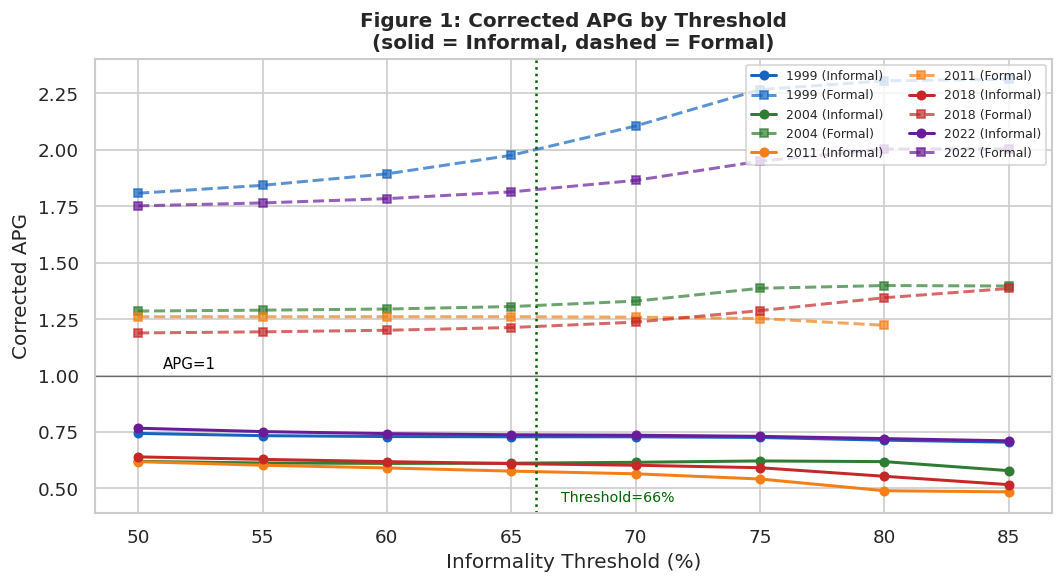

In [5]:
thresholds  = list(range(50, 86, 5))
all_results = pd.concat(
    [compute_informal_formal_apg(klems, yr_codes, years, th) for th in thresholds],
    ignore_index=True
)

colors_yr = {1999:'#1565C0', 2004:'#2E7D32', 2011:'#F57F17', 2018:'#C62828', 2022:'#6A1B9A'}

fig, ax = plt.subplots(figsize=(9, 5))
for yr in years:
    sub = all_results[all_results['Year'] == yr]
    ax.plot(sub['threshold'], sub['unorg_correct_APG'],
            marker='o', markersize=5, linewidth=1.8,
            color=colors_yr[yr], label=f'{yr} (Informal)')
    ax.plot(sub['threshold'], sub['org_correct_APG'],
            marker='s', markersize=5, linewidth=1.8,
            color=colors_yr[yr], linestyle='--', alpha=0.7, label=f'{yr} (Formal)')

ax.axhline(y=1,  color='black',     linestyle='-',  linewidth=0.8, alpha=0.5)
ax.axvline(x=66, color='darkgreen', linestyle=':',  linewidth=1.5)
ax.text(67, ax.get_ylim()[0] + 0.05, 'Threshold=66%', fontsize=8.5, color='darkgreen')
ax.text(51, 1.03, 'APG=1', fontsize=9, color='black')
ax.set_xlabel('Informality Threshold (%)')
ax.set_ylabel('Corrected APG')
ax.set_title('Figure 1: Corrected APG by Threshold\n(solid = Informal, dashed = Formal)', fontweight='bold')
ax.legend(fontsize=7.5, ncol=2, loc='upper right')
plt.tight_layout()
plt.show()

---
## Part 5: Sector-Level Long Dataset — APG by Informality Share

In [6]:
long_rows = []
for yr, yc in zip(years, yr_codes):
    agri_row = klems[klems['sector27'] == 'agri_forest_fish'].iloc[0]
    VA_ag    = 10000 * agri_row[f'VA_r{yc}'] / agri_row[f'EMP{yc}']
    EDU_ag   = agri_row[f'edu_yrs{yc}']
    HRS_ag   = agri_row[f'hours{yc}']
    LSH_ag   = agri_row[f'LSH_VA{yc}']

    for _, row in klems[klems['sector27'] != 'agri_forest_fish'].iterrows():
        va_pw    = 10000 * row[f'VA_r{yc}'] / row[f'EMP{yc}']
        raw_APG  = va_pw / VA_ag
        lsh_adj  = LSH_ag      / row[f'LSH_VA{yc}']
        hrs_adj  = row[f'hours{yc}']   / HRS_ag
        hcap_adj = np.exp(0.07 * row[f'edu_yrs{yc}']) / np.exp(0.07 * EDU_ag)

        APG1 = raw_APG
        APG2 = APG1 / lsh_adj
        APG3 = APG2 / hrs_adj
        APG4 = APG3 / hcap_adj

        long_rows.append({
            'sector27'        : row['sector27'],
            'year'            : yr,
            'informal_emp_per': row[f'unorg_{yc}'],
            'APG1'            : round(APG1, 3),
            'APG2'            : round(APG2, 3),
            'APG3'            : round(APG3, 3),
            'correct_APG'     : round(APG4, 3),
        })

apg_long = pd.DataFrame(long_rows)
print('Sector-year observations:', len(apg_long))

# Quick diagnostic: does corrected APG approach 1 at high informality?
bins = pd.cut(apg_long['informal_emp_per'], bins=[0,25,50,75,100])
print()
print('Mean corrected APG by informality bin:')
print(apg_long.groupby(bins, observed=True)['correct_APG'].mean().round(3))

Sector-year observations: 130

Mean corrected APG by informality bin:
informal_emp_per
(0, 25]      1.448
(25, 50]     1.183
(50, 75]     0.821
(75, 100]    0.649
Name: correct_APG, dtype: float64


---
## Part 6: Figure 2 — Nonparametric Estimation

### Why Nonparametric?

We do not want to assume the relationship between informality and APG is linear. Instead we estimate:
$$y_i = f(x_i) + \varepsilon_i$$
where $f$ is an unknown smooth function estimated using **local linear regression** — fitting a line using only nearby observations, weighted by a Gaussian kernel.

### Null Hypothesis
Under perfect mobility: $H_0: f(x) = 1$ for all $x$.

When the 95% bootstrap confidence band **includes 1**, we fail to reject — no significant gap.  
When the band **excludes 1**, the gap is statistically significant.

In [7]:
y_all = apg_long['correct_APG'].values
x_all = (apg_long['informal_emp_per'] / 100).values

sort_idx = np.argsort(x_all)
x_s      = x_all[sort_idx]
y_s      = y_all[sort_idx]

# Fit kernel regression with cross-validation bandwidth selection
kr     = KernelReg(endog=y_s, exog=x_s, var_type='c', reg_type='ll', bw='cv_ls')
print(f'Cross-validation bandwidth: {kr.bw[0]:.4f}')

# Bootstrap confidence intervals
np.random.seed(42)
n_boot    = 100
n_obs     = len(x_s)
x_grid    = np.linspace(x_s.min(), x_s.max(), 80)
boot_fits = np.zeros((n_boot, len(x_grid)))

for b in range(n_boot):
    idx      = np.random.choice(n_obs, n_obs, replace=True)
    x_b      = x_s[idx];  y_b = y_s[idx]
    s        = np.argsort(x_b)
    kr_b     = KernelReg(endog=y_b[s], exog=x_b[s], var_type='c', reg_type='ll', bw=[kr.bw[0]])
    fit_b, _ = kr_b.fit(x_grid)
    boot_fits[b] = fit_b

ci_lo = np.percentile(boot_fits, 2.5,  axis=0)
ci_hi = np.percentile(boot_fits, 97.5, axis=0)

kr_grid    = KernelReg(endog=y_s, exog=x_s, var_type='c', reg_type='ll', bw=[kr.bw[0]])
y_grid, _  = kr_grid.fit(x_grid)

# Find where CI first includes 1
ci_includes_1 = (ci_lo <= 1) & (ci_hi >= 1)
first_include = x_grid[ci_includes_1][0] if ci_includes_1.any() else None
print(f'CI first includes 1 at x = {first_include:.3f} ({first_include*100:.1f}% informal)' if first_include else 'CI never includes 1')

Cross-validation bandwidth: 0.1313
CI first includes 1 at x = 0.450 (45.0% informal)


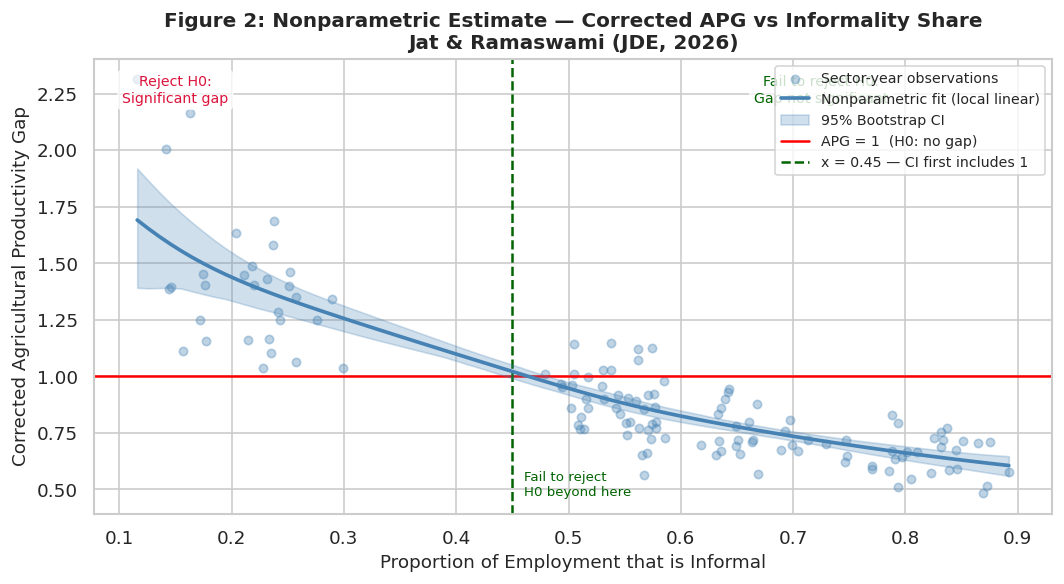


Reading Figure 2:
  For x < 0.45: CI excludes 1 → significant APG → reject H0
  For x > 0.45: CI includes 1 → gap disappears → fail to reject H0
  Interpretation: agriculture and highly informal non-farm sectors
  have statistically equal productivity once we adjust for hours, human capital,
  and labor share. The APG is a formal/informal divide, not ag/non-ag.


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(x_s, y_s, color='steelblue', s=25, alpha=0.35, zorder=2, label='Sector-year observations')
ax.plot(x_grid, y_grid, color='steelblue', linewidth=2.2, zorder=4, label='Nonparametric fit (local linear)')
ax.fill_between(x_grid, ci_lo, ci_hi, alpha=0.25, color='steelblue', zorder=3, label='95% Bootstrap CI')
ax.axhline(y=1, color='red', linestyle='-', linewidth=1.5, label='APG = 1  (H0: no gap)')

if first_include:
    ax.axvline(x=first_include, color='darkgreen', linestyle='--', linewidth=1.5,
               label=f'x = {first_include:.2f} — CI first includes 1')
    ax.text(first_include + 0.01, ax.get_ylim()[0] + 0.08,
            f'Fail to reject\nH0 beyond here', fontsize=8, color='darkgreen')

# Annotate the two regions
ylims = ax.get_ylim()
ax.text(0.15, ylims[1]*0.92, 'Reject H0:\nSignificant gap',
        fontsize=8.5, color='crimson', ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
if first_include and first_include < 0.95:
    ax.text((first_include + 1.0)/2, ylims[1]*0.92, 'Fail to reject H0:\nGap not significant',
            fontsize=8.5, color='darkgreen', ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_xlabel('Proportion of Employment that is Informal', fontsize=11)
ax.set_ylabel('Corrected Agricultural Productivity Gap', fontsize=11)
ax.set_title('Figure 2: Nonparametric Estimate — Corrected APG vs Informality Share\n'
             'Jat & Ramaswami (JDE, 2026)', fontweight='bold')
ax.legend(fontsize=8.5, loc='upper right')
plt.tight_layout()
plt.show()

print()
print('Reading Figure 2:')
print(f'  For x < {first_include:.2f}: CI excludes 1 → significant APG → reject H0')
print(f'  For x > {first_include:.2f}: CI includes 1 → gap disappears → fail to reject H0')
print('  Interpretation: agriculture and highly informal non-farm sectors')
print('  have statistically equal productivity once we adjust for hours, human capital,')
print('  and labor share. The APG is a formal/informal divide, not ag/non-ag.')

---
## Part 7: Figure 3 — Successive Adjustments

How much does each adjustment reduce the gap?

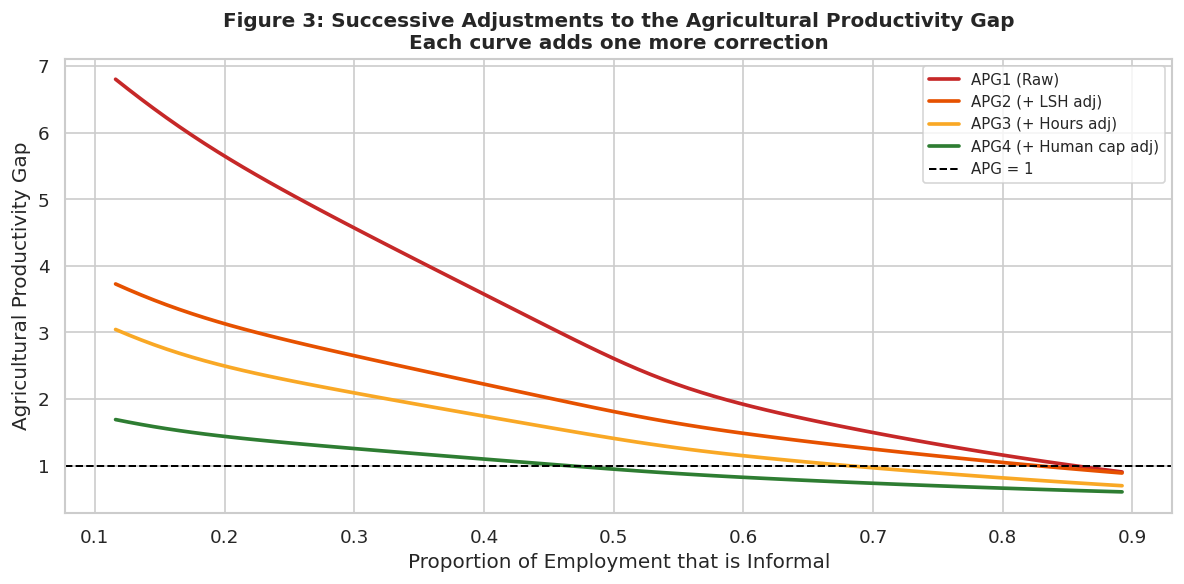


Reading Figure 3:
  Red curve (raw): large gap at all informality levels
  Each adjustment pushes the curve closer to 1
  Green curve (fully corrected): reaches 1 at high informality
  All adjustments together eliminate the gap for highly informal sectors


In [9]:
apg_versions = {
    'APG1 (Raw)'            : ('APG1',        '#C62828'),
    'APG2 (+ LSH adj)'      : ('APG2',        '#E65100'),
    'APG3 (+ Hours adj)'    : ('APG3',        '#F9A825'),
    'APG4 (+ Human cap adj)': ('correct_APG', '#2E7D32'),
}

sort_all = np.argsort(x_all)
x_s_all  = x_all[sort_all]
x_grid3  = np.linspace(x_s_all.min(), x_s_all.max(), 80)

fig, ax = plt.subplots(figsize=(10, 5))

for label, (col, color) in apg_versions.items():
    y_col    = apg_long[col].values[sort_all]
    kr_v     = KernelReg(endog=y_col, exog=x_s_all, var_type='c', reg_type='ll', bw=[kr.bw[0]])
    y_v, _   = kr_v.fit(x_grid3)
    ax.plot(x_grid3, y_v, linewidth=2.2, color=color, label=label)

ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, label='APG = 1')
ax.set_xlabel('Proportion of Employment that is Informal')
ax.set_ylabel('Agricultural Productivity Gap')
ax.set_title('Figure 3: Successive Adjustments to the Agricultural Productivity Gap\n'
             'Each curve adds one more correction', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print()
print('Reading Figure 3:')
print('  Red curve (raw): large gap at all informality levels')
print('  Each adjustment pushes the curve closer to 1')
print('  Green curve (fully corrected): reaches 1 at high informality')
print('  All adjustments together eliminate the gap for highly informal sectors')

---
## Part 8: Table 6 — Employment Share Where APG is Not Different from 1

In [10]:
def compute_high_informal_emp(klems, yr_codes, years, threshold=76):
    results = []
    for yr, yc in zip(years, yr_codes):
        nonagri = klems[klems['sector27'] != 'agri_forest_fish'].copy()
        nonagri['high_inf'] = (nonagri[f'unorg_{yc}'] > threshold).astype(int)
        total   = nonagri[f'EMP{yc}'].sum()
        inf_emp = (nonagri[f'EMP{yc}'] * nonagri['high_inf']).sum()
        results.append({'Year': yr, 'High_Informal_EMP_Share_pct': round(100 * inf_emp / total, 2)})
    return pd.DataFrame(results)

table6 = compute_high_informal_emp(klems, yr_codes, years, threshold=76)

print('=== TABLE 6: Share of Non-Farm Employment in Sectors Where APG is Not Different from 1 ===')
print('(Sectors with informality share > 76%)')
print()
print(table6.to_string(index=False))
print()
print('A substantial fraction of non-farm employment is in sectors')
print('so informal that their productivity gap from agriculture is not statistically significant.')

=== TABLE 6: Share of Non-Farm Employment in Sectors Where APG is Not Different from 1 ===
(Sectors with informality share > 76%)

 Year  High_Informal_EMP_Share_pct
 1999                        15.45
 2004                        26.02
 2011                        25.06
 2018                        17.40
 2022                        19.48

A substantial fraction of non-farm employment is in sectors
so informal that their productivity gap from agriculture is not statistically significant.


---
## Part 9: The Main Message

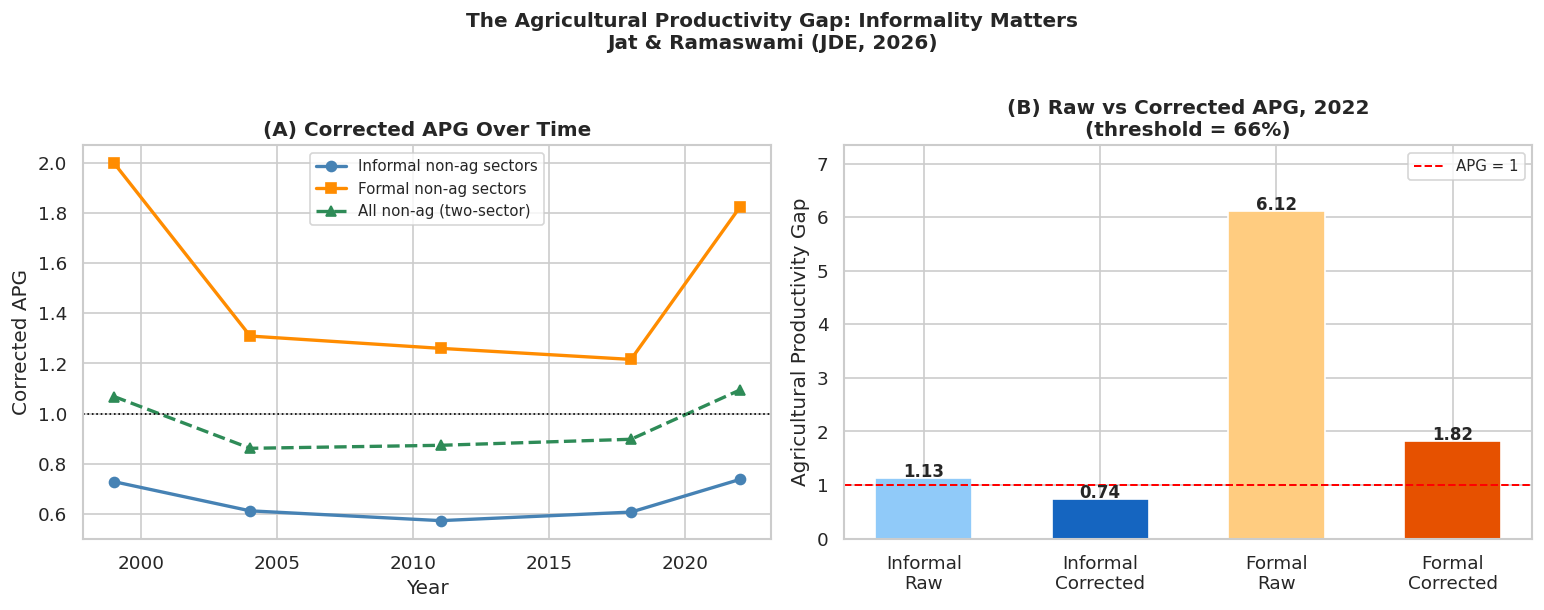


Main finding:
  Corrected APG (vs Informal sectors, 2022): 0.738
  Corrected APG (vs Formal sectors,   2022): 1.822

  The gap between agriculture and informal non-farm sectors is close to 1.
  The large overall APG is driven by the formal sector premium.
  Policy implication: barriers between formal and informal labor markets
  — not between agriculture and non-agriculture — drive the APG.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: corrected APG over time
axes[0].plot(df66['Year'], df66['unorg_correct_APG'],
             marker='o', linewidth=2, color='steelblue', label='Informal non-ag sectors')
axes[0].plot(df66['Year'], df66['org_correct_APG'],
             marker='s', linewidth=2, color='darkorange', label='Formal non-ag sectors')
axes[0].plot(table1['Year'], table1['Corrected_APG'],
             marker='^', linewidth=2, color='seagreen', linestyle='--', label='All non-ag (two-sector)')
axes[0].axhline(y=1, color='black', linestyle=':', linewidth=1)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Corrected APG')
axes[0].set_title('(A) Corrected APG Over Time', fontweight='bold')
axes[0].legend(fontsize=9)

# Right: raw vs corrected bar chart (2022)
latest = df66[df66['Year'] == 2022].iloc[0]
cats   = ['Informal\nRaw', 'Informal\nCorrected', 'Formal\nRaw', 'Formal\nCorrected']
vals   = [latest['unorg_raw_APG'], latest['unorg_correct_APG'],
          latest['org_raw_APG'],   latest['org_correct_APG']]
colors_b = ['#90CAF9','#1565C0','#FFCC80','#E65100']

bars = axes[1].bar(cats, vals, color=colors_b, edgecolor='white', width=0.55)
for bar, val in zip(bars, vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
axes[1].axhline(y=1, color='red', linestyle='--', linewidth=1.2, label='APG = 1')
axes[1].set_ylabel('Agricultural Productivity Gap')
axes[1].set_title('(B) Raw vs Corrected APG, 2022\n(threshold = 66%)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, max(vals) * 1.2)

plt.suptitle('The Agricultural Productivity Gap: Informality Matters\nJat & Ramaswami (JDE, 2026)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print()
print('Main finding:')
print(f'  Corrected APG (vs Informal sectors, 2022): {latest["unorg_correct_APG"]:.3f}')
print(f'  Corrected APG (vs Formal sectors,   2022): {latest["org_correct_APG"]:.3f}')
print()
print('  The gap between agriculture and informal non-farm sectors is close to 1.')
print('  The large overall APG is driven by the formal sector premium.')
print('  Policy implication: barriers between formal and informal labor markets')
print('  — not between agriculture and non-agriculture — drive the APG.')

---
## Summary

| Section | What We Did | Python Tools |
|---------|------------|---------------|
| Table 1 | Two-sector APG with hours, human capital, LSH adjustments | Pandas, NumPy |
| Table 4 | Informal vs formal APG with EMP × deviation² weights | Pandas, NumPy |
| Figure 1 | Threshold sensitivity (50%–85%) | Matplotlib |
| Figure 2 | Nonparametric regression + bootstrap CI | statsmodels KernelReg |
| Figure 3 | Successive adjustment curves | statsmodels KernelReg |
| Table 6 | Share of non-farm EMP in high-informal sectors | Pandas |

### Key Concepts
- **Mincer return**: $e^{0.07 \times \text{Edu}}$ — 7% wage return per year of schooling
- **Labor share adjustment**: corrects for differences in how output is split between capital and labor
- **Nonparametric regression**: estimates $f(x)$ without assuming a functional form
- **Bootstrap CI**: resample 100 times to measure uncertainty around the nonparametric fit
- **Hypothesis testing**: $H_0: f(x) = 1$ rejected when CI excludes 1

---
*ECON N171 | Summer 2026*